# 5.2.- Clasificación de CIFAR-10

En este experimento se entrena una red neuronal convolucional (CNN) construida manualmente para clasificar las imágenes del dataset **CIFAR-10**.

El conjunto CIFAR-10 contiene 60 000 imágenes a color (32×32 píxeles) distribuidas en 10 clases:
avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco y camión.

El objetivo es construir una CNN sencilla pero funcional, entrenarla con callbacks para optimizar el proceso y evaluar su rendimiento mediante *accuracy* y una matriz de confusión.

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(33)
tf.random.set_seed(33)

## Carga y preprocesamiento del dataset CIFAR-10

CIFAR-10 ya está disponible directamente en Keras y se carga con un simple comando.  
Las imágenes tienen formato RGB (32×32×3), por lo que no requieren conversión de canales.  

Pasos aplicados:
1. Carga del dataset y división en entrenamiento y prueba.  
2. Normalización de los valores de píxel al rango [0, 1].  
3. Conversión de las etiquetas a codificación *one-hot* (10 clases).  
4. Visualización de algunas imágenes deejemplo.


In [23]:
# Cargar dataset CIFAR-10
(X_train, y_train_raw), (X_test, y_test_raw) = keras.datasets.cifar10.load_data()

# Normalización
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Codificación one-hot de las etiquetas
num_classes = 10
y_train = keras.utils.to_categorical(y_train_raw, num_classes)
y_test = keras.utils.to_categorical(y_test_raw, num_classes)

# Mostrar forma de los datos
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (50000, 32, 32, 3)
y_train: (50000, 10)


## Data Augmentation

Antes de construir la CNN, se define una capa de **Data Augmentation** que genera variaciones aleatorias de las imágenes de entrenamiento.  
Esto ayuda al modelo a generalizar mejor, simulando condiciones distintas (rotaciones, volteos, zoom, etc.) sin necesidad de aumentar realmente el dataset.

El bloque aplica las siguientes transformaciones:
- Volteo horizontal aleatorio.
- Rotación aleatoria de ±10 %.
- Zoom aleatorio de hasta un 10 %.

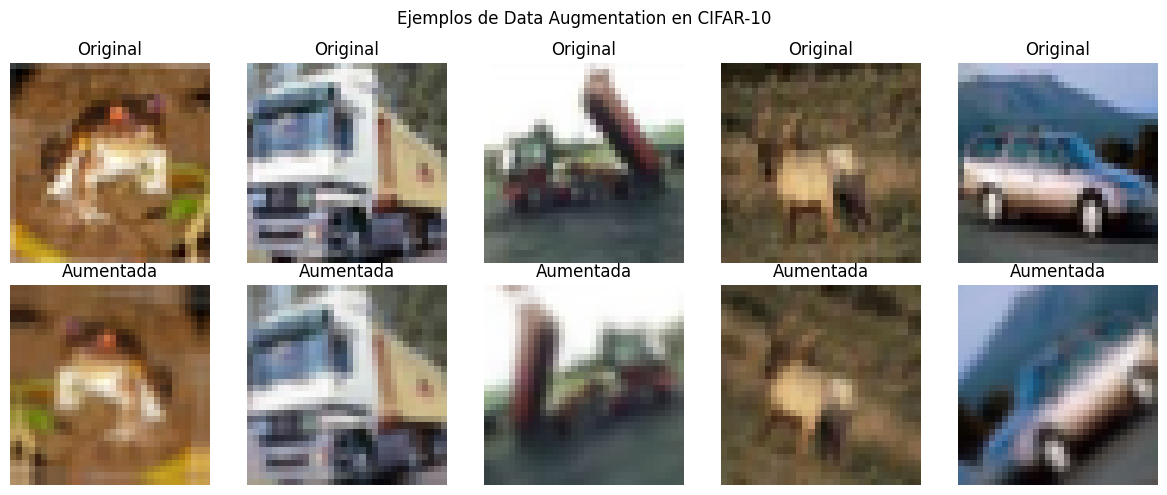

In [24]:
# Definición del bloque de aumento de datos
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# Visualización de ejemplos aumentados
sample_images = X_train[:5]
augmented_images = data_augmentation(sample_images)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(sample_images[i])
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")
    axes[1, i].imshow(augmented_images[i].numpy().astype("float32"))
    axes[1, i].set_title("Aumentada")
    axes[1, i].axis("off")

plt.suptitle("Ejemplos de Data Augmentation en CIFAR-10")
plt.tight_layout()
plt.show()

## Construcción del modelo CNN
Se define una red convolucional profunda y robusta adaptada al dataset CIFAR-10.  
El objetivo es mejorar la capacidad de generalización mediante una arquitectura moderna, con normalización, regularización y aumento de datos.

### Características principales

- **Aumento de datos integrado**: aplica rotaciones, volteos y zoom aleatorios para mejorar la generalización.  
- **Bloques convolucionales apilados**: tres bloques con filtros 32, 64 y 128, cada uno con dos convoluciones y normalización intermedia.  
- **Regularización progresiva**: capas *Dropout* con probabilidades crecientes para reducir el sobreajuste.  
- **Capa densa compacta**: 128 neuronas con *BatchNormalization* antes de la salida *softmax*.  
- **Optimizador**: Adam con tasa de aprendizaje inicial de 1e-3. clase).


In [25]:
model = models.Sequential([
    # Definición explícita de la entrada
    keras.Input(shape=(32, 32, 3)),
    
    # Bloque de aumento de datos
    data_augmentation,

    # Bloque 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Bloque 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Bloque 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # Clasificación
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compilación del modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           51

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

## Visualización del modelo

En esta celda se genera un diagrama con `keras.utils.plot_model()` para comprobar la estructura de la CNN y los tamaños de salida de cada capa.  
La imagen se guarda automáticamente en el mismo directorio que el notebook.

In [26]:
# Inicializar las capas llamando al modelo una vez
_ = model(X_train[:1])

# Ruta de guardado del diagrama
output_path = os.path.join(os.getcwd(), "cnn_cifar10.png")

# Generar y guardar el diagrama
plot_model(model, to_file=output_path, show_shapes=True, show_layer_names=True)
print(f"Imagen guardada en: {output_path}")

Imagen guardada en: /tf/cnn_cifar10.png


## Callbacks del entrenamiento

Para optimizar el entrenamiento y evitar sobreajuste se utilizan tres callbacks fundamentales:

- **ReduceLROnPlateau:** reduce la tasa de aprendizaje cuando la pérdida de validación deja de mejorar, ayudando a una convergencia más estable.
- **ModelCheckpoint:** guarda automáticamente el mejor modelo alcanzado durante el entrenamiento.
- **EarlyStopping:** detiene el entrenamiento cuando el modelo deja de mejorar después de varios epoch consecutivos.

Estos mecanismos permiten mantener el mejor rendimiento sin desperdiciar tiempo ni recursos computacionales.

In [27]:
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=0
    ),
    ModelCheckpoint(
        filepath='cnn_cifar10_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )
]

## Entrenamiento del modelo

El modelo se entrena utilizando el conjunto de entrenamiento, reservando un 10 % de los datos para validación.  
Durante el proceso, los callbacks ajustan automáticamente la tasa de aprendizaje, detienen el entrenamiento si no hay mejora y guardan el mejor modelo obtenido.

In [28]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.2634 - loss: 2.4963 - val_accuracy: 0.0950 - val_loss: 2.8274 - learning_rate: 0.0010
Epoch 2/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 93ms/step - accuracy: 0.4162 - loss: 1.6823 - val_accuracy: 0.1104 - val_loss: 3.5181 - learning_rate: 0.0010
Epoch 3/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.4764 - loss: 1.4960 - val_accuracy: 0.1426 - val_loss: 3.8839 - learning_rate: 0.0010
Epoch 4/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 0.5196 - loss: 1.3574 - val_accuracy: 0.1876 - val_loss: 3.4394 - learning_rate: 0.0010
Epoch 5/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.5553 - loss: 1.2504 - val_accuracy: 0.3770 - val_loss: 1.7630 - learning_rate: 5.0000e-04
Epoch 6/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.5799 - loss: 1.1833 - val_accuracy: 0.6202 - val_loss: 1.0957 - learning_rate: 5.0000e-04
Epoch 7/30
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.5957 - loss: 1.1377 -

## Evaluación del modelo

Una vez finalizado el entrenamiento, se evalúa el rendimiento del modelo sobre el conjunto de prueba.  
Se calculan las métricas de pérdida (*loss*) y exactitud (*accuracy*), y se representan las curvas de aprendizaje para observar la evolución del entrenamiento.

In [29]:
# Evaluación del modelo sobre el conjunto de prueba
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

Accuracy: 0.7684
Pérdida: 0.6671


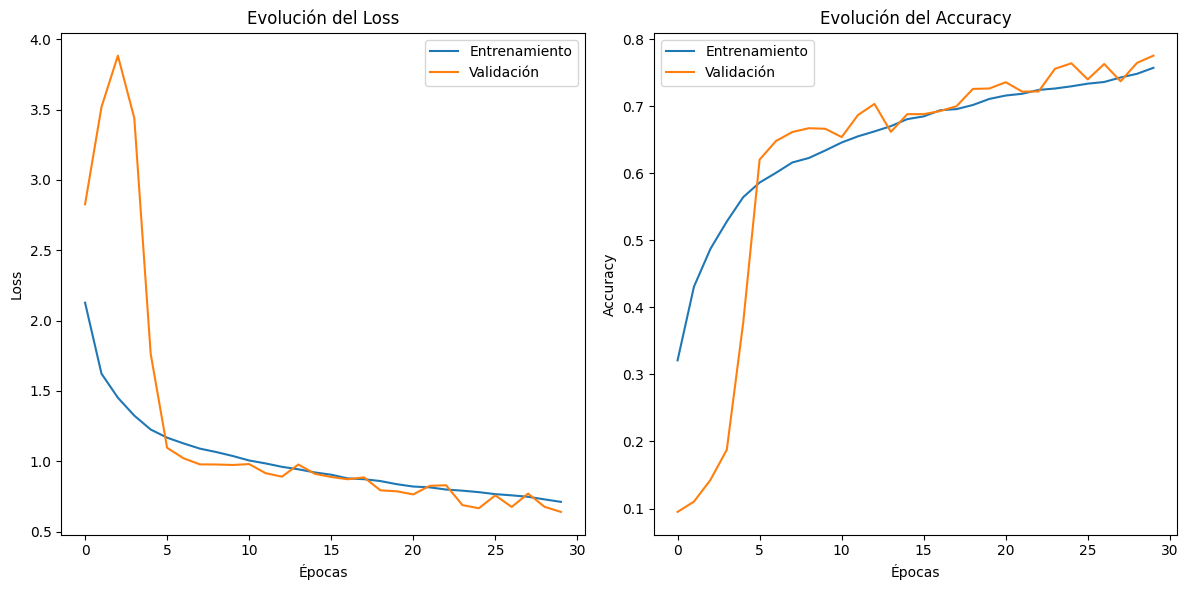

In [30]:
print(f"Accuracy: {test_acc:.4f}")
print(f"Pérdida: {test_loss:.4f}")

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Evolución del Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Evolución del Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Matriz de confusión

Se genera una matriz de confusión para analizar los aciertos y errores del modelo en cada clase.  
Esto permite observar en qué categorías se confunde más y cuáles predice con mayor precisión.

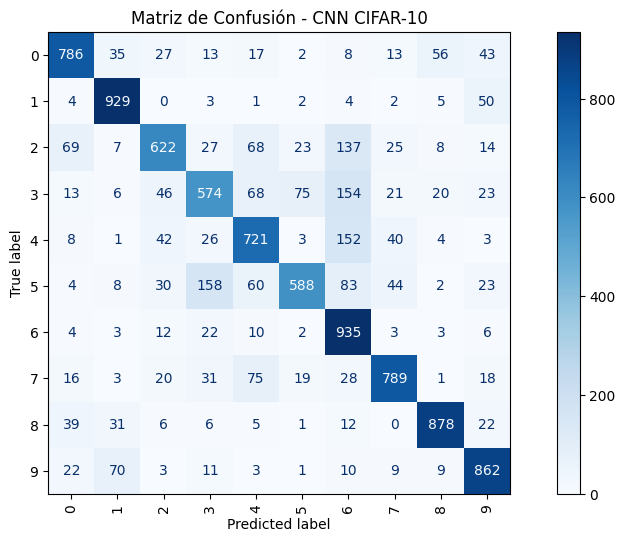

In [31]:
# Predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Matriz de Confusión - CNN CIFAR-10")
plt.show()

## Guardado y carga del modelo

El modelo entrenado se guarda en el nuevo formato nativo de Keras (`.keras`), recomendado a partir de TensorFlow 2.13.  
Este formato conserva toda la información necesaria: arquitectura, pesos, optimizador y estado del entrenamiento.  
Posteriormente puede cargarse directamente con `keras.models.load_model()` sin pérdida de información.

In [32]:
# Guardar el modelo en formato .keras (recomendado)
model.save("cnn_cifar10_final.keras")
print("Modelo guardado como cnn_cifar10_final.keras")

# Cargar el modelo (para comprobación)
loaded_model = keras.models.load_model("cnn_cifar10_final.keras")
print("Modelo cargado correctamente desde .keras")

Modelo guardado como cnn_cifar10_final.keras
Modelo cargado correctamente desde .keras


## Predicciones de ejemplo

Para comprobar el rendimiento del modelo se muestran algunas imágenes del conjunto de prueba junto con su etiqueta real y la predicha por la red.  
Esto permite observar visualmente la capacidad de generalización del modelo.

In [33]:
# Obtener predicciones en algunas imágenes de test
indices = np.random.choice(len(X_test), 5, replace=False)
images = X_test[indices]
labels_true = y_test_raw[indices].flatten()
labels_pred = np.argmax(model.predict(images), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


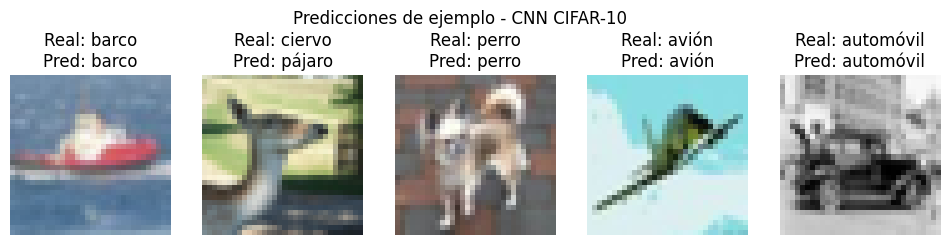

In [34]:
# Nombres de las clases de CIFAR-10
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Visualización
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.axis("off")
    ax.set_title(f"Real: {class_names[labels_true[i]]}\nPred: {class_names[labels_pred[i]]}")
plt.suptitle("Predicciones de ejemplo - CNN CIFAR-10")
plt.show()